### Load packages

In [38]:
import pandas as pd
import os
import textwrap
import numpy as np

# for figures
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.dates as mdates
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
from pandas.plotting import scatter_matrix

### Set project parameters for this run

In [39]:
# Project parameters

data_directory = r"..\data\merged_csvs"

algae_file = "algae_merged"
algae_path = os.path.join(data_directory, algae_file + ".csv")
print(algae_path)

..\data\merged_csvs\algae_merged.csv


### Load algae bloom data

In [40]:
# Load algae bloom data file

algae_raw_df = pd.read_csv(algae_path)

In [41]:
algae_raw_df.iloc[:5, :]
# vct_raw_df.iloc[:10, 10:25]
# vct_raw_df.iloc[:10, 10:25]

,vct_region,vct_report_date,vct_latitude,vct_longitude,vct_water_temp_trailing,vct_water_surface_trailing,vct_anabaena_trailing,vct_aphanizomenon_trailing,vct_microcystin_trailing,vct_oscillatoria_trailing,...,noaa_WDF5,noaa_TAVG,dec_total nitrogen,dec_total phosphorus,dec_dissolved phosphorus,dec_chlorophyll-a,dec_secchi depth,dec_temperature,vct_target_bloom,vct_target_bloom_intensity
0,Main Lake Central,2014-09-30,44.484736,-73.288936,66.608333,Calm,1.0,1.0,0.0,1.0,...,211.428571,15.228571,0.340,12.5,5.00,3.830,5.40,NaN,0,1a
1,Main Lake Central,2014-10-02,44.484736,-73.288936,66.169167,Calm,1.0,1.0,0.0,1.0,...,233.571429,15.328571,0.340,12.5,5.00,3.830,5.40,NaN,1,3
2,Main Lake Central,2015-06-14,44.484736,-73.288936,65.625000,Calm,1.0,0.0,0.0,0.0,...,254.285714,16.521429,0.400,69.6,13.00,2.300,5.00,12.0,0,1b
3,Main Lake Central,2015-06-15,44.484736,-73.288936,65.597222,Calm,1.0,0.0,0.0,0.0,...,250.000000,16.992857,0.400,69.6,13.00,2.300,5.00,12.0,0,1a
4,Main Lake Central,2015-06-16,44.484736,-73.288936,65.347222,Calm,1.0,0.0,0.0,0.0,...,252.142857,17.557143,0.405,39.7,9.65,1.815,4.05,14.2,0,1a


In [42]:
print(len(algae_raw_df.columns))
algae_raw_df.columns

35


Index(['vct_region', 'vct_report_date', 'vct_latitude', 'vct_longitude',
       'vct_water_temp_trailing', 'vct_water_surface_trailing',
       'vct_anabaena_trailing', 'vct_aphanizomenon_trailing',
       'vct_microcystin_trailing', 'vct_oscillatoria_trailing',
       'usgs_water_temp_max_trailing', 'usgs_water_temp_min_trailing',
       'usgs_water_temp_mean_trailing', 'usgs_conductivity_max_trailing',
       'usgs_conductivity_min_trailing', 'usgs_conductivity_mean_trailing',
       'noaa_PRCP', 'noaa_TMAX', 'noaa_TMIN', 'noaa_AWND', 'noaa_WSF2',
       'noaa_SNWD', 'noaa_WDF2', 'noaa_SNOW', 'noaa_WSF5', 'noaa_WDF5',
       'noaa_TAVG', 'dec_total nitrogen', 'dec_total phosphorus',
       'dec_dissolved phosphorus', 'dec_chlorophyll-a', 'dec_secchi depth',
       'dec_temperature', 'vct_target_bloom', 'vct_target_bloom_intensity'],
      dtype='object')

In [43]:
# Convert number columns to floats and integers as appropriate

algae_numcols_df = algae_raw_df.copy()

float_cols = ["vct_water_temp_trailing", "usgs_water_temp_max_trailing", "usgs_water_temp_min_trailing", "usgs_water_temp_mean_trailing", 
              "usgs_conductivity_max_trailing", "usgs_conductivity_min_trailing", "usgs_conductivity_mean_trailing",
              "noaa_PRCP", "noaa_TMIN", "noaa_TMAX", "noaa_AWND", "noaa_WDF2", "noaa_WSF2", "noaa_SNWD", "noaa_SNOW",
              "noaa_WSF5", "noaa_WDF5", "noaa_TAVG", "dec_total nitrogen", "dec_total phosphorus", "dec_dissolved phosphorus",
              "dec_chlorophyll-a", "dec_secchi depth", "dec_temperature"]
int_cols = ["vct_anabaena_trailing", "vct_aphanizomenon_trailing", "vct_microcystin_trailing", "vct_oscillatoria_trailing",
             "vct_target_bloom"]

algae_numcols_df[float_cols] = algae_numcols_df[float_cols].apply(pd.to_numeric, errors="coerce")

algae_numcols_df[int_cols] = (algae_numcols_df[int_cols].apply(pd.to_numeric, errors="coerce").astype("Int64"))

algae_numcols_df.head()

,vct_region,vct_report_date,vct_latitude,vct_longitude,vct_water_temp_trailing,vct_water_surface_trailing,vct_anabaena_trailing,vct_aphanizomenon_trailing,vct_microcystin_trailing,vct_oscillatoria_trailing,...,noaa_WDF5,noaa_TAVG,dec_total nitrogen,dec_total phosphorus,dec_dissolved phosphorus,dec_chlorophyll-a,dec_secchi depth,dec_temperature,vct_target_bloom,vct_target_bloom_intensity
0,Main Lake Central,2014-09-30,44.484736,-73.288936,66.608333,Calm,1,1,0,1,...,211.428571,15.228571,0.340,12.5,5.00,3.830,5.40,NaN,0,1a
1,Main Lake Central,2014-10-02,44.484736,-73.288936,66.169167,Calm,1,1,0,1,...,233.571429,15.328571,0.340,12.5,5.00,3.830,5.40,NaN,1,3
2,Main Lake Central,2015-06-14,44.484736,-73.288936,65.625000,Calm,1,0,0,0,...,254.285714,16.521429,0.400,69.6,13.00,2.300,5.00,12.0,0,1b
3,Main Lake Central,2015-06-15,44.484736,-73.288936,65.597222,Calm,1,0,0,0,...,250.000000,16.992857,0.400,69.6,13.00,2.300,5.00,12.0,0,1a
4,Main Lake Central,2015-06-16,44.484736,-73.288936,65.347222,Calm,1,0,0,0,...,252.142857,17.557143,0.405,39.7,9.65,1.815,4.05,14.2,0,1a


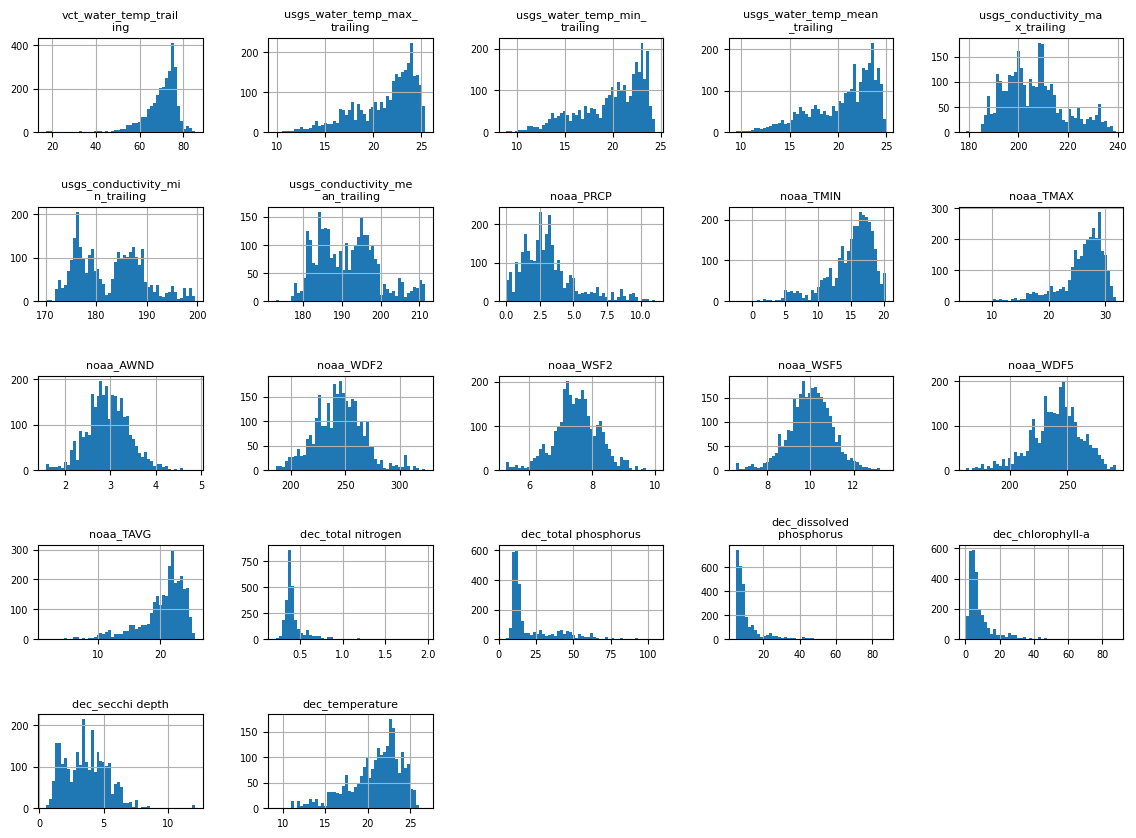

In [44]:
# Plot histograms of the numerical columns in the data

use_log_values = False

histo_cols = ["vct_water_temp_trailing", "usgs_water_temp_max_trailing", "usgs_water_temp_min_trailing", "usgs_water_temp_mean_trailing", 
              "usgs_conductivity_max_trailing", "usgs_conductivity_min_trailing", "usgs_conductivity_mean_trailing",
              "noaa_PRCP", "noaa_TMIN", "noaa_TMAX", "noaa_AWND", "noaa_WDF2", "noaa_WSF2",
              "noaa_WSF5", "noaa_WDF5", "noaa_TAVG", "dec_total nitrogen", "dec_total phosphorus", "dec_dissolved phosphorus",
              "dec_chlorophyll-a", "dec_secchi depth", "dec_temperature"]

plot_df =  algae_numcols_df[histo_cols].apply(pd.to_numeric, errors="coerce")

# Compute logs if needed
if use_log_values:
    safe_plot_df = plot_df.where(plot_df > -1)
    safe_plot_df = np.log10(safe_plot_df + 1)
else:
    safe_plot_df = plot_df.copy()

# drop columns that are all nulls or NaN values
safe_plot_df = safe_plot_df.dropna(axis=1, how="all")

axes = safe_plot_df.hist(bins=50, figsize=(14, 10), layout=(5, 5))

for ax in axes.flatten():
    title = ax.get_title()
    wrapped_title = "\n".join(textwrap.wrap(title, width=20))
    ax.set_title(wrapped_title, fontsize=8)
    ax.tick_params(axis="y", labelsize=7)
    ax.tick_params(axis="x", labelsize=7)

plt.subplots_adjust(hspace=0.8, wspace=0.4)

plt.show()


In [45]:
algae_numcols_df.columns

Index(['vct_region', 'vct_report_date', 'vct_latitude', 'vct_longitude',
       'vct_water_temp_trailing', 'vct_water_surface_trailing',
       'vct_anabaena_trailing', 'vct_aphanizomenon_trailing',
       'vct_microcystin_trailing', 'vct_oscillatoria_trailing',
       'usgs_water_temp_max_trailing', 'usgs_water_temp_min_trailing',
       'usgs_water_temp_mean_trailing', 'usgs_conductivity_max_trailing',
       'usgs_conductivity_min_trailing', 'usgs_conductivity_mean_trailing',
       'noaa_PRCP', 'noaa_TMAX', 'noaa_TMIN', 'noaa_AWND', 'noaa_WSF2',
       'noaa_SNWD', 'noaa_WDF2', 'noaa_SNOW', 'noaa_WSF5', 'noaa_WDF5',
       'noaa_TAVG', 'dec_total nitrogen', 'dec_total phosphorus',
       'dec_dissolved phosphorus', 'dec_chlorophyll-a', 'dec_secchi depth',
       'dec_temperature', 'vct_target_bloom', 'vct_target_bloom_intensity'],
      dtype='object')

In [46]:
# Find counts for all the categorical columns

cat_cols = ["vct_region", 
            "vct_water_surface_trailing",
            "vct_anabaena_trailing",
            "vct_aphanizomenon_trailing",
            "vct_microcystin_trailing",
            "vct_oscillatoria_trailing",
            "vct_target_bloom",
            "vct_target_bloom_intensity"
]

for col in cat_cols:
    print(algae_numcols_df[col].value_counts(), "\n")


vct_region
Main Lake Central    897
Main Lake South      767
St. Albans Bay       477
Missisquoi Bay       424
Malletts Bay         354
Name: count, dtype: int64 

vct_water_surface_trailing
Calm          2367
Rolling        550
White Caps       2
Name: count, dtype: int64 

vct_anabaena_trailing
1    1730
0    1189
Name: count, dtype: Int64 

vct_aphanizomenon_trailing
1    1996
0     923
Name: count, dtype: Int64 

vct_microcystin_trailing
1    1498
0    1421
Name: count, dtype: Int64 

vct_oscillatoria_trailing
0    2438
1     481
Name: count, dtype: Int64 

vct_target_bloom
0    2210
1     709
Name: count, dtype: Int64 

vct_target_bloom_intensity
1a    921
1c    513
1b    472
3     422
1d    304
2     287
Name: count, dtype: int64 



In [57]:
# Format the data for time plots

algae_plots_df = algae_numcols_df.copy()

algae_plots_df["vct_report_date"] = pd.to_datetime(algae_plots_df["vct_report_date"])
algae_plots_df["year"] = algae_plots_df["vct_report_date"].dt.year

algae_plots_df = algae_plots_df[algae_plots_df["vct_report_date"].dt.year != 2014]

# Count records per date per year
date_counts = (
    algae_plots_df
    .groupby(["year", "vct_region", "vct_report_date"])
    .size()
    .reset_index(name="count")
)

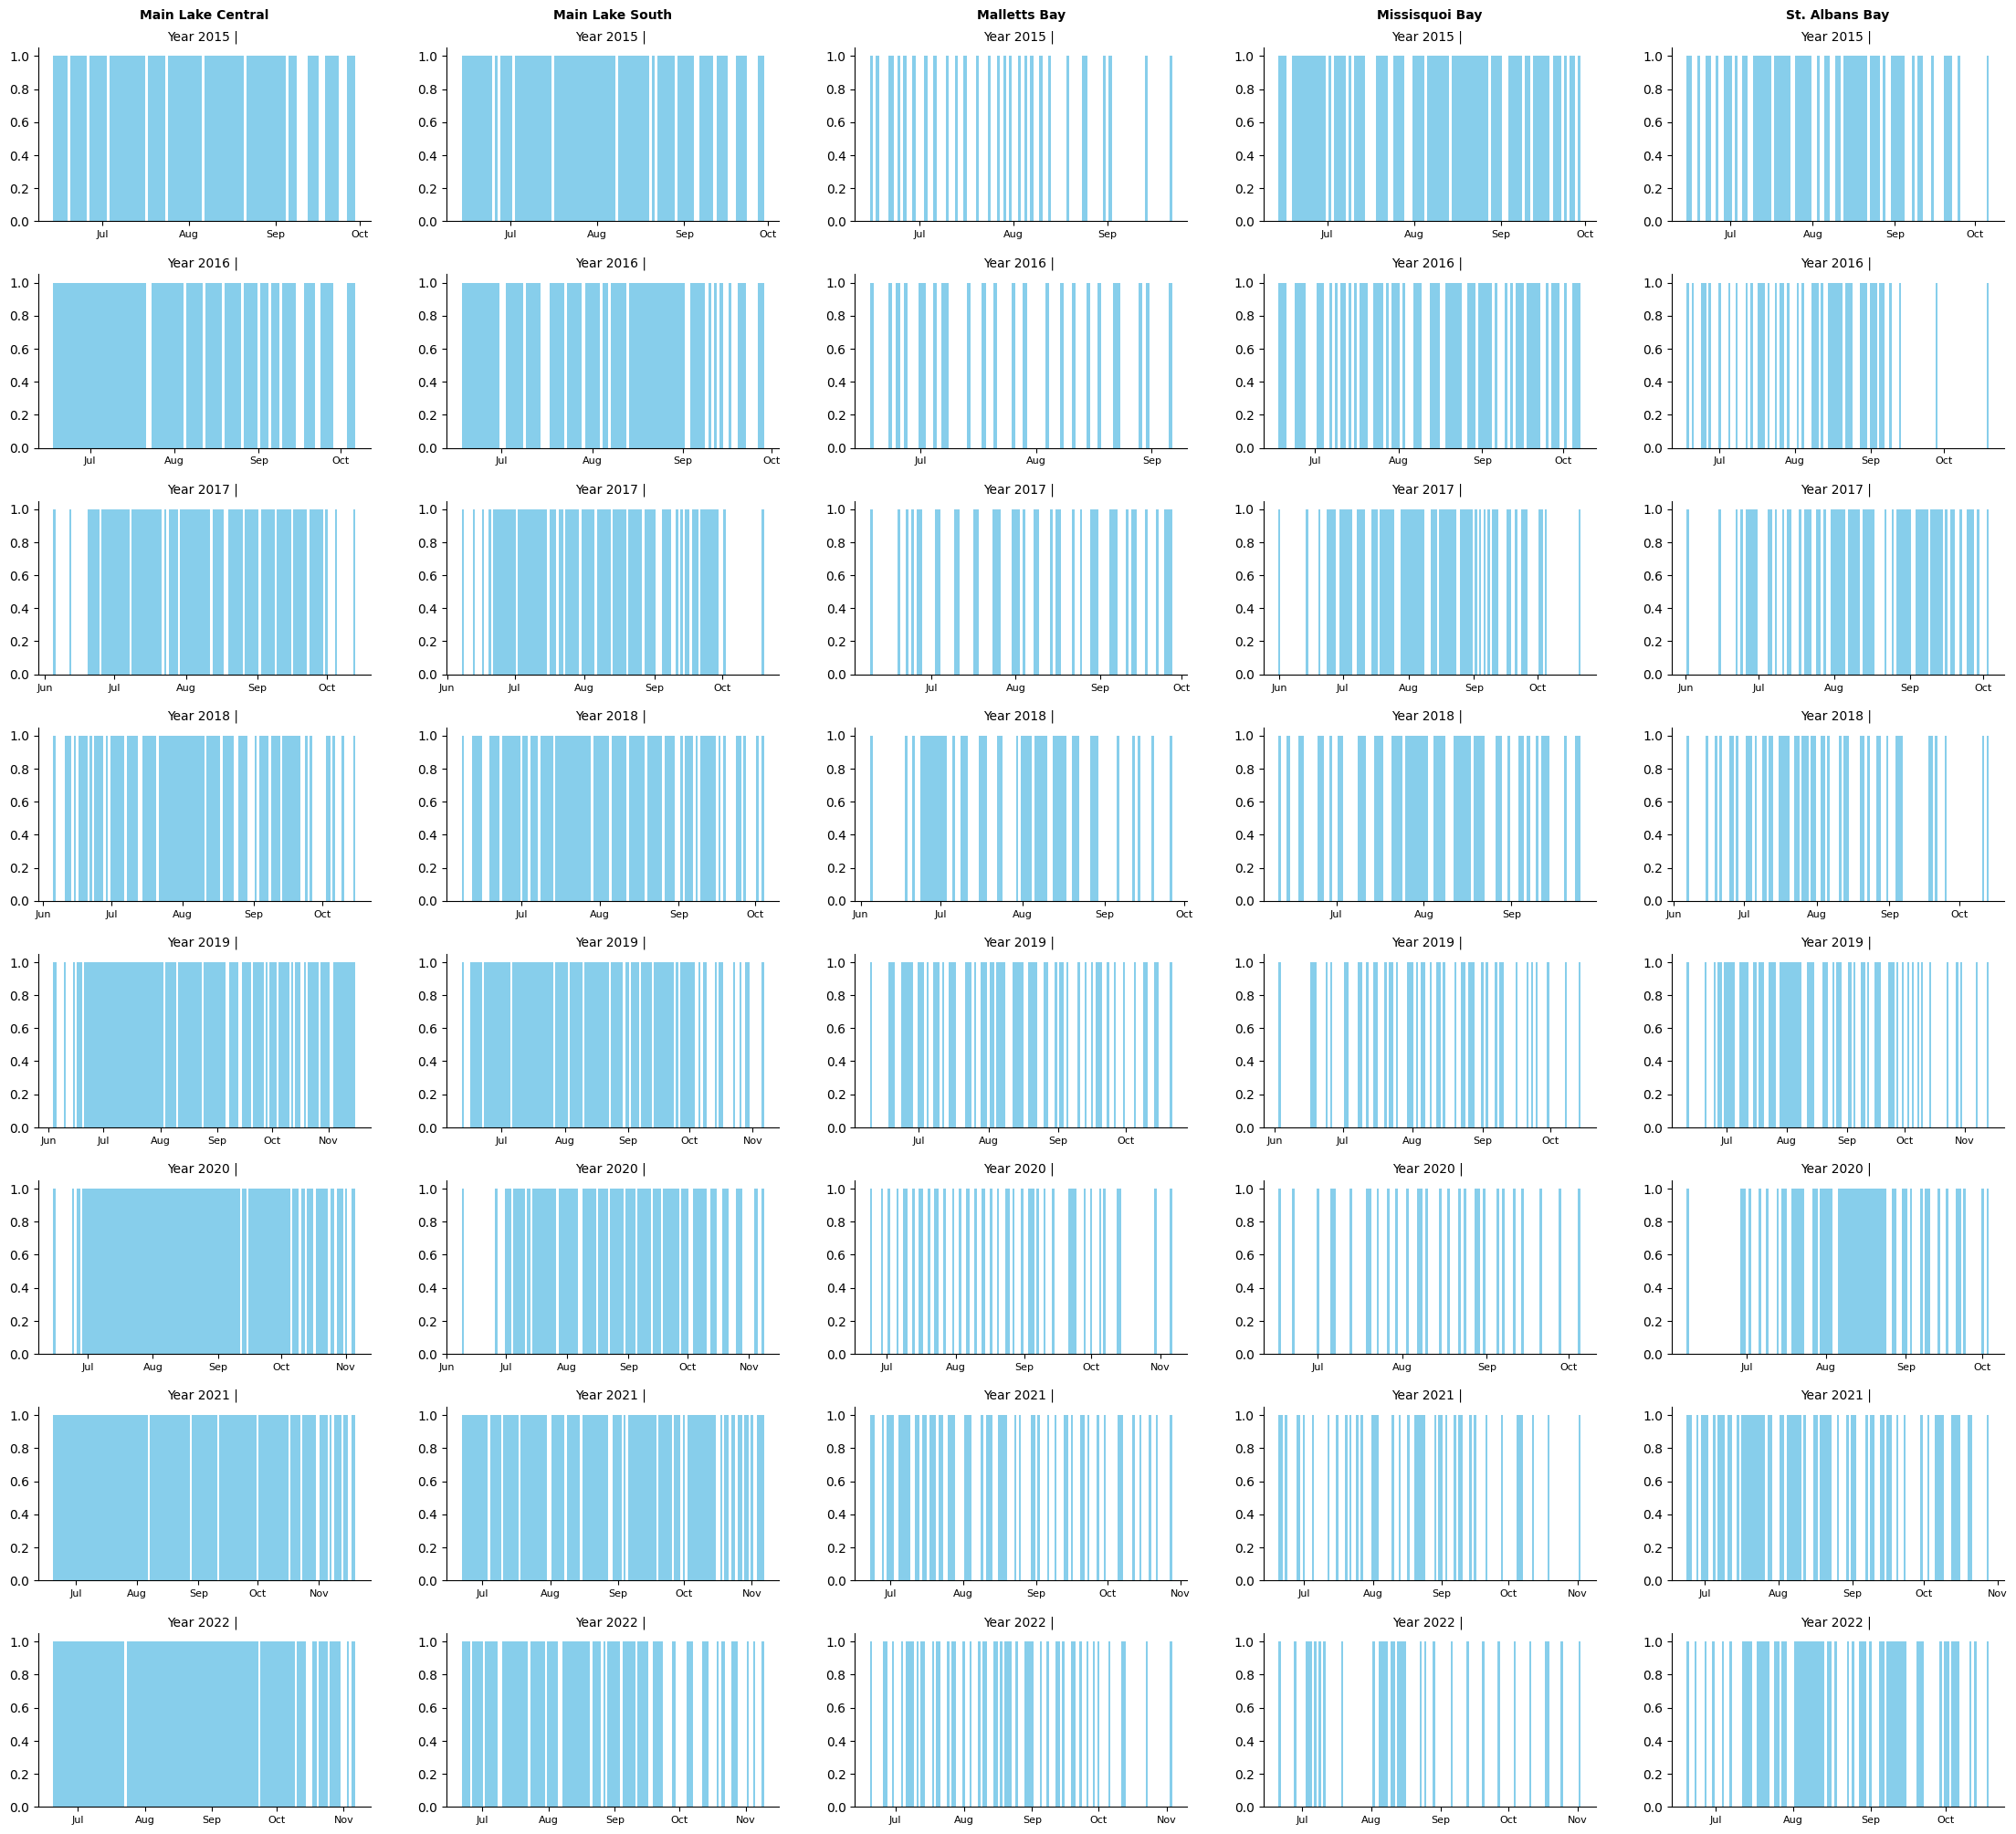

In [64]:
# Time plot - bar graphs per year

def barplot_datetime(data, **kwargs):
    ax = plt.gca()
    ax.bar(
        data["vct_report_date"],
        data["count"],
        color="skyblue",
        # edgecolor="black",
        width=1
    )

g = sns.FacetGrid(
    date_counts,
    row="year",
    col="vct_region",
    height=2.5,
    aspect=1.8,
    sharex=False,
    sharey=False
)

g.map_dataframe(barplot_datetime)

# Remove column names from subplot titles
g.set_titles(row_template="Year {row_name}", col_template="")

# Add region names at top of each column
regions = date_counts["vct_region"].sort_values().unique()
nrows, ncols = g.axes.shape
for col_idx, region in enumerate(regions):
    ax_top = g.axes[0, col_idx]
    ax_top.annotate(
        region,
        xy=(0.5, 1.15),
        xycoords="axes fraction",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Format x-axis
for ax in g.axes.flat:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.tick_params(axis="x", labelsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")


In [ ]:
# Compute correlation coefficients for every number variable

corr_cols = ["vct_water_temp_trailing", "usgs_water_temp_max_trailing", "usgs_water_temp_min_trailing", "usgs_water_temp_mean_trailing", 
              "usgs_conductivity_max_trailing", "usgs_conductivity_min_trailing", "usgs_conductivity_mean_trailing",
              "noaa_PRCP", "noaa_TMIN", "noaa_TMAX", "noaa_AWND", "noaa_WDF2", "noaa_WSF2",
              "noaa_WSF5", "noaa_WDF5", "noaa_TAVG", "dec_total nitrogen", "dec_total phosphorus", "dec_dissolved phosphorus",
              "dec_chlorophyll-a", "dec_secchi depth", "dec_temperature"]


corr_matrix = algae_plots_df[corr_cols].corr()

for corr_col in corr_cols:
    print(corr_matrix[corr_col].sort_values(ascending=False).round(2), "\n")


vct_water_temp_trailing            1.00
usgs_water_temp_max_trailing       0.55
usgs_water_temp_mean_trailing      0.55
usgs_water_temp_min_trailing       0.54
noaa_TMAX                          0.48
noaa_TAVG                          0.45
noaa_TMIN                          0.43
noaa_WDF5                          0.19
dec_total phosphorus               0.14
dec_chlorophyll-a                  0.08
noaa_WDF2                          0.04
dec_total nitrogen                -0.02
usgs_conductivity_max_trailing    -0.03
usgs_conductivity_mean_trailing   -0.04
noaa_WSF2                         -0.10
usgs_conductivity_min_trailing    -0.11
noaa_WSF5                         -0.12
dec_secchi depth                  -0.13
noaa_PRCP                         -0.17
noaa_AWND                         -0.20
Name: vct_water_temp_trailing, dtype: float64 

usgs_water_temp_max_trailing       1.00
usgs_water_temp_mean_trailing      1.00
usgs_water_temp_min_trailing       0.98
noaa_TMIN                       

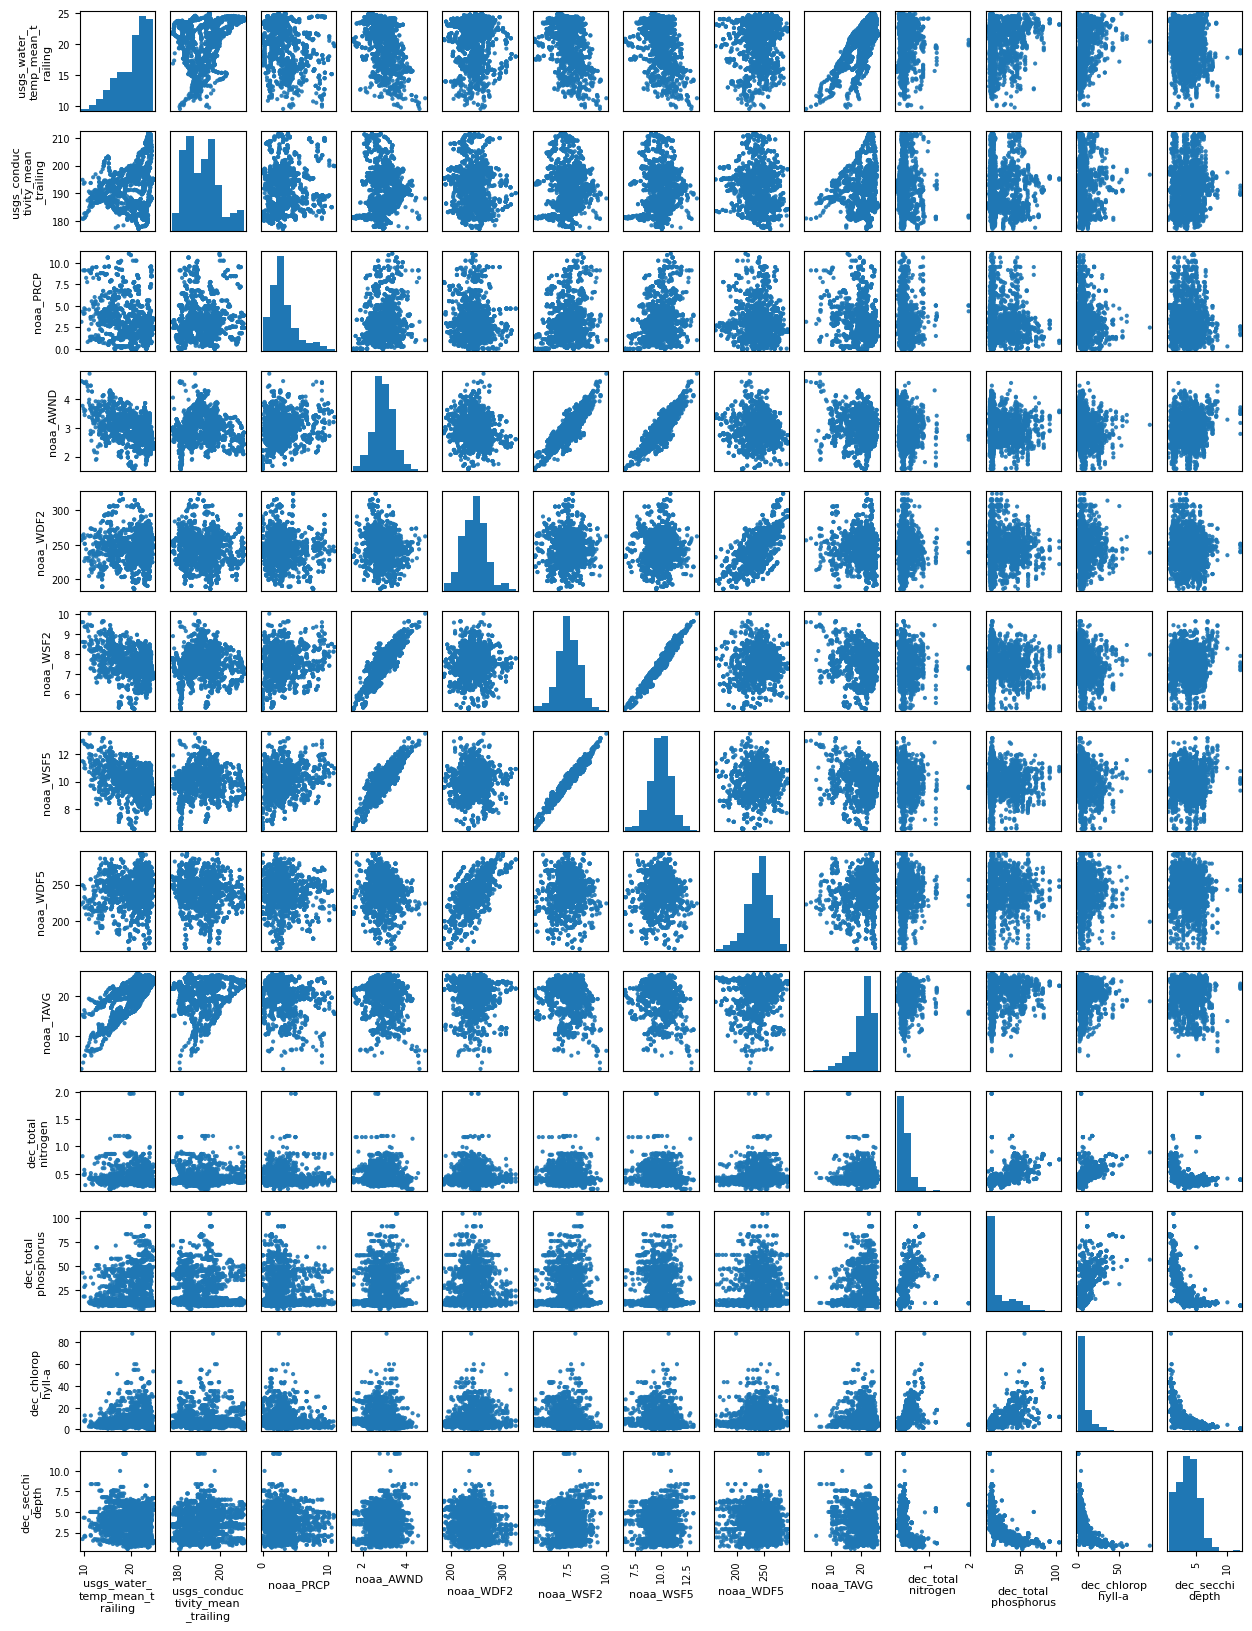

In [85]:
# Calculate scatterplots for every number variable pair

use_log_values = False

scatter_cols = ["usgs_water_temp_mean_trailing", 
              "usgs_conductivity_mean_trailing",
              "noaa_PRCP", "noaa_AWND", "noaa_WDF2", "noaa_WSF2",
              "noaa_WSF5", "noaa_WDF5", "noaa_TAVG", "dec_total nitrogen", "dec_total phosphorus",
              "dec_chlorophyll-a", "dec_secchi depth"]

plot_df = algae_plots_df[scatter_cols].apply(pd.to_numeric, errors="coerce")

# Compute logs if needed
if use_log_values:
    safe_plot_df = plot_df.where(plot_df > -1)
    safe_plot_df = np.log10(safe_plot_df + 1)
else:
    safe_plot_df = plot_df.copy()
    
axes = scatter_matrix(safe_plot_df[scatter_cols], figsize=(15, 20), alpha=0.9)

for ax in axes.flatten():
    # Wrap x-label
    xlabel = ax.get_xlabel()
    wrapped_xlabel = "\n".join(textwrap.wrap(xlabel, width=11))
    ax.set_xlabel(wrapped_xlabel, fontsize=8)

    # Wrap y-label
    ylabel = ax.get_ylabel()
    wrapped_ylabel = "\n".join(textwrap.wrap(ylabel, width=11))
    ax.set_ylabel(wrapped_ylabel, fontsize=8)

    # Optional: reduce tick label size
    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

plt.subplots_adjust(hspace=0.2, wspace=0.2)
plt.show()

In [70]:
# Compute correlations for all number variables

# Compute correlation matrix
corr_matrix = algae_plots_df[corr_cols].corr()

# Take the upper triangle to avoid duplicates and self-correlations
corr_matrix_upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Unstack to get pairs
corr_pairs = corr_matrix_upper.unstack().dropna()

In [73]:
# Sort by absolute correlation (descending)
corr_pairs_sorted = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)

# Show top pairs
print(corr_pairs_sorted.head(30))

usgs_water_temp_mean_trailing    usgs_water_temp_max_trailing      0.995505
                                 usgs_water_temp_min_trailing      0.993340
noaa_TAVG                        noaa_TMAX                         0.988225
usgs_water_temp_min_trailing     usgs_water_temp_max_trailing      0.978692
noaa_TAVG                        noaa_TMIN                         0.977880
noaa_WSF5                        noaa_WSF2                         0.972510
noaa_TMAX                        noaa_TMIN                         0.942407
usgs_conductivity_mean_trailing  usgs_conductivity_min_trailing    0.922235
                                 usgs_conductivity_max_trailing    0.920222
dec_temperature                  usgs_water_temp_max_trailing      0.870159
noaa_WSF2                        noaa_AWND                         0.867115
noaa_WSF5                        noaa_AWND                         0.867097
dec_temperature                  usgs_water_temp_mean_trailing     0.862894
            

In [77]:
# Save the correlations to a csv

# Take upper triangle to avoid duplicates and self-correlations
corr_matrix = algae_plots_df[corr_cols].corr()
corr_matrix_upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_pairs = corr_matrix_upper.unstack().dropna()

# Sort by absolute correlation
corr_pairs_sorted = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)

# Convert to DataFrame
corr_df = corr_pairs_sorted.reset_index()
corr_df.columns = ["Variable 1", "Variable 2", "Correlation"]

# Optional: round correlations to 2 decimals
corr_df["Correlation"] = corr_df["Correlation"].round(2)

# Save to CSV
corr_df.to_csv(r"..\data\merged_csvs\numerical_feature_correlations.csv", index=False)